<a href="https://colab.research.google.com/github/AndreMarques2002/Churn_E_Commerce/blob/main/Churn_E_Commerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Projeto: Previsão de Churn no E-commerce com Machine Learning**

**Objetivo:** Desenvolver um modelo preditivo capaz de identificar clientes com alta probabilidade de abandono (Churn) utilizando dados comportamentais e transacionais.

**Abordagem:** Realizaremos uma Análise Exploratória de Dados (EDA) profunda, tratamento de valores ausentes, engenharia de atributos e, por fim, o treinamento de um modelo de Random Forest, avaliando não apenas sua acurácia, mas métricas críticas de negócio como Recall e F1-Score.

In [ ]:
# Importação das bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc

# Configurações visuais
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')


caminho_arquivo = '/content/E Commerce Dataset.xlsx'
df = pd.read_excel(caminho_arquivo, sheet_name='E Comm')

# Visualização inicial
display(df.head())
print(f"Formato do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.")

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


Formato do dataset: 5630 linhas e 20 colunas.


# **Limpeza e Tratamento de Dados (Data Cleaning)**
A qualidade do modelo depende da qualidade dos dados. Vamos identificar valores nulos e aplicar estratégias de imputação baseadas na distribuição de cada variável. O ID do cliente será removido, pois não carrega poder preditivo.

In [ ]:
# Removendo a coluna CustomerID
df = df.drop('CustomerID', axis=1)

# Verificando dados nulos
nulos = df.isnull().sum()
print("Valores Nulos por Coluna:\n", nulos[nulos > 0])

# Estratégia de Imputação: Usaremos a mediana para variáveis numéricas
# para mitigar o efeito de possíveis outliers.
colunas_com_nulos = df.columns[df.isnull().any()].tolist()

for col in colunas_com_nulos:
    if df[col].dtype in ['int64', 'float64']:
        mediana = df[col].median()
        df[col].fillna(mediana, inplace=True)
    else:
        moda = df[col].mode()[0]
        df[col].fillna(moda, inplace=True)

print("\nTotal de nulos após o tratamento:", df.isnull().sum().sum())

Valores Nulos por Coluna:
 Tenure                         264
WarehouseToHome                251
HourSpendOnApp                 255
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
dtype: int64

Total de nulos após o tratamento: 0


# **Análise Exploratória de Dados (EDA) - Univariada e Bivariada**
Nesta etapa, vamos entender a distribuição da nossa variável alvo (Churn) e como as variáveis de negócio se relacionam com ela. Gráficos variados nos ajudarão a extrair insights visuais antes mesmo de aplicarmos Machine Learning.

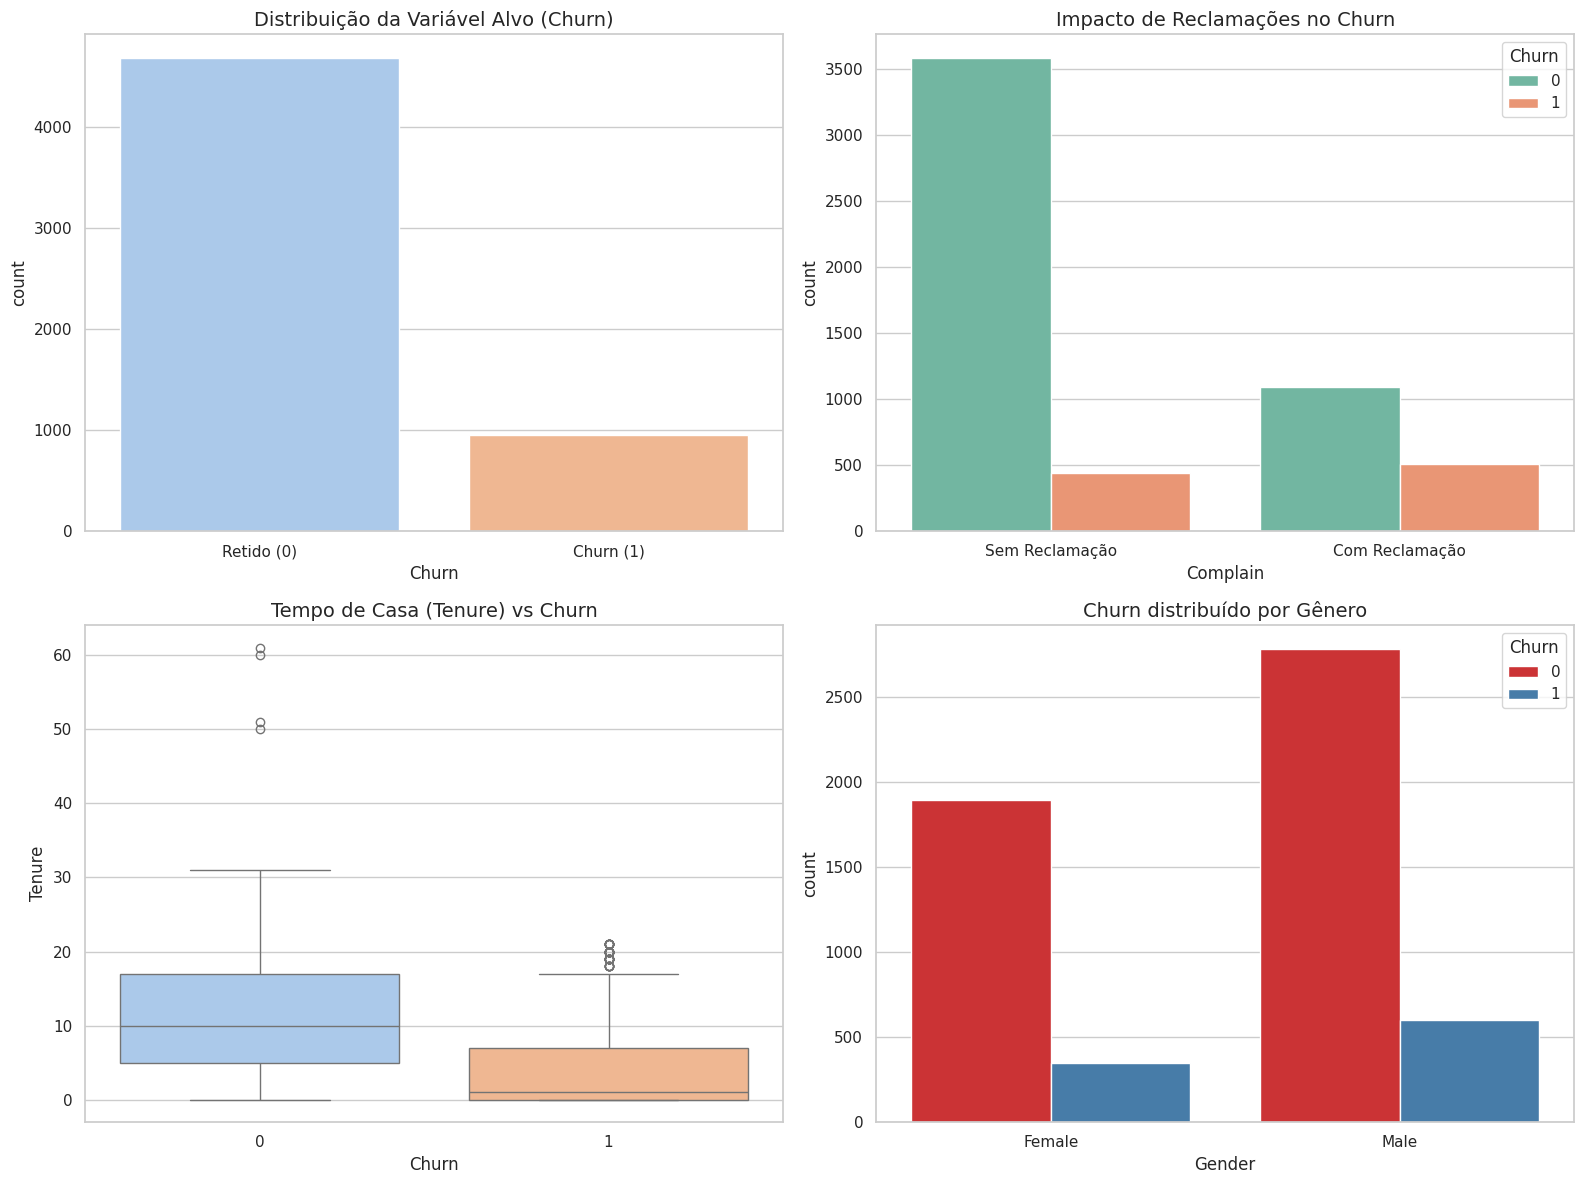

In [ ]:
# Criando uma figura com múltiplos gráficos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribuição da Variável Alvo (Churn)
sns.countplot(x='Churn', data=df, ax=axes[0, 0], palette='pastel')
axes[0, 0].set_title('Distribuição da Variável Alvo (Churn)', fontsize=14)
axes[0, 0].set_xticklabels(['Retido (0)', 'Churn (1)'])

# 2. Churn por Reclamação (Complain)
sns.countplot(x='Complain', hue='Churn', data=df, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Impacto de Reclamações no Churn', fontsize=14)
axes[0, 1].set_xticklabels(['Sem Reclamação', 'Com Reclamação'])

# 3. Distribuição do Tempo de Casa (Tenure) vs Churn
sns.boxplot(x='Churn', y='Tenure', data=df, ax=axes[1, 0], palette='pastel')
axes[1, 0].set_title('Tempo de Casa (Tenure) vs Churn', fontsize=14)

# 4. Churn por Gênero
sns.countplot(x='Gender', hue='Churn', data=df, ax=axes[1, 1], palette='Set1')
axes[1, 1].set_title('Churn distribuído por Gênero', fontsize=14)

plt.tight_layout()
plt.show()

# **Análise de Correlação (Multivariada)**
Para entender como as variáveis numéricas interagem entre si, a Matriz de Correlação é a ferramenta ideal. Ela nos ajuda a identificar redundâncias (multicolinearidade) e padrões ocultos.

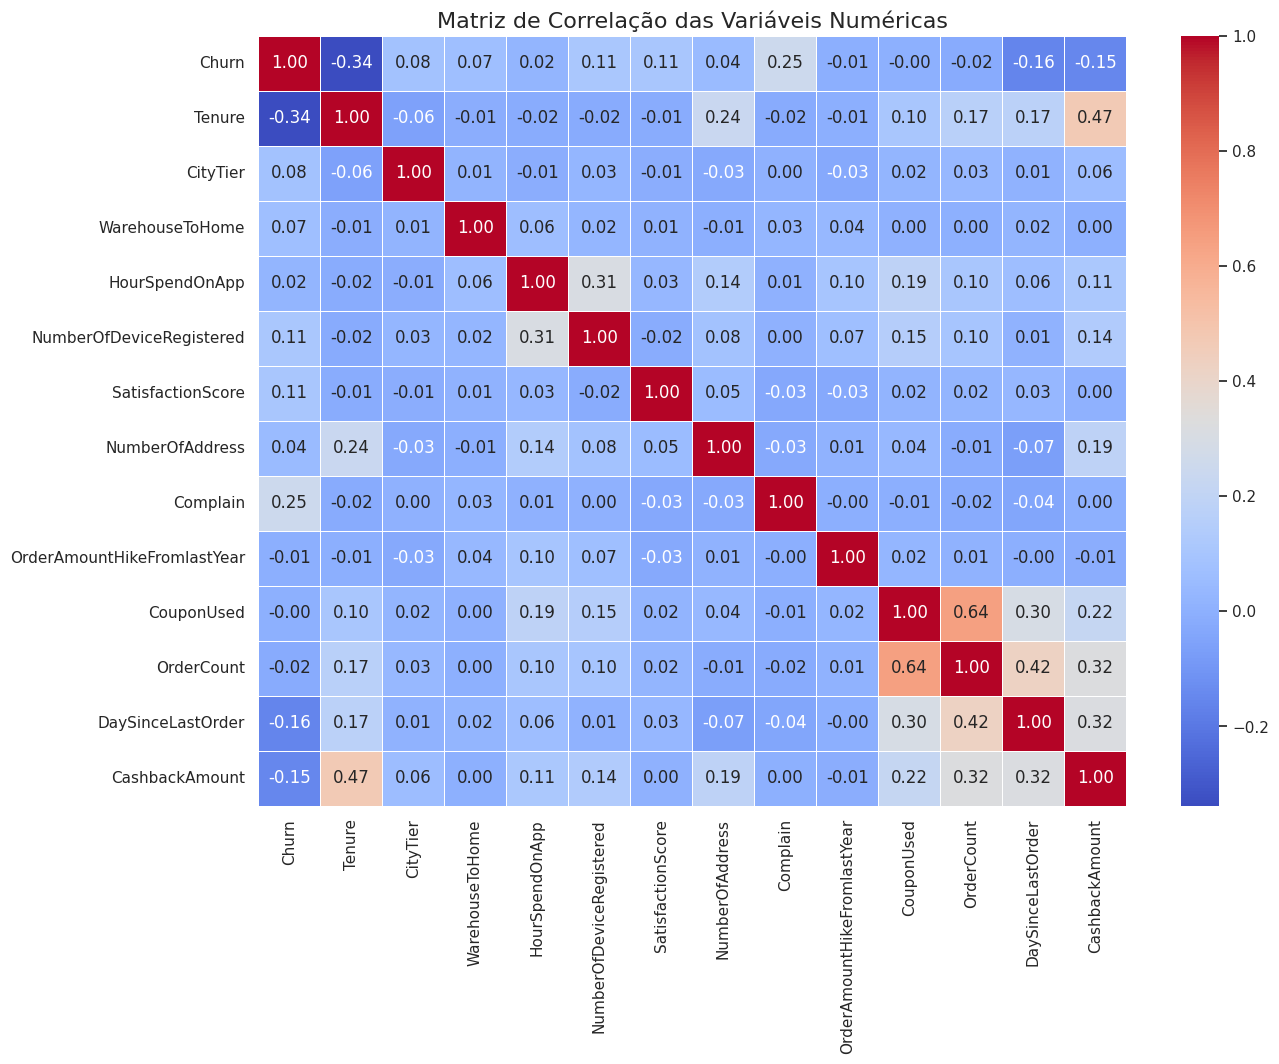

In [ ]:
plt.figure(figsize=(14, 10))
# Selecionando apenas colunas numéricas
colunas_numericas = df.select_dtypes(include=['int64', 'float64']).columns
matriz_correlacao = df[colunas_numericas].corr()

# Criando o Heatmap
sns.heatmap(matriz_correlacao, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlação das Variáveis Numéricas', fontsize=16)
plt.show()

# **Engenharia de Atributos e Pré-processamento**
Modelos de Machine Learning requerem dados numéricos. Vamos transformar nossas variáveis categóricas (texto) em colunas binárias utilizando One-Hot Encoding. Em seguida, separaremos os dados em Treino e Teste.

In [ ]:
# Aplicando One-Hot Encoding nas variáveis categóricas
df_model = pd.get_dummies(df, drop_first=True)

# Separando Variáveis Preditoras (X) e Variável Alvo (y)
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# Divisão em Treino (80%) e Teste (20%)
# O parâmetro 'stratify=y' garante que a proporção de Churn seja mantida nas duas bases
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamanho do Treino: {X_train.shape[0]} amostras")
print(f"Tamanho do Teste: {X_test.shape[0]} amostras")

Tamanho do Treino: 4504 amostras
Tamanho do Teste: 1126 amostras


# **Treinamento do Modelo (Random Forest)**
Utilizaremos o Random Forest (Floresta Aleatória). É um algoritmo robusto, baseado em múltiplas árvores de decisão. Ele lida excepcionalmente bem com dados não lineares e não exige que os dados sejam padronizados na mesma escala.

In [ ]:
# Instanciando o modelo
rf_model = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, class_weight='balanced')

# Treinando o modelo
rf_model.fit(X_train, y_train)

# Realizando as predições na base de teste
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# **Avaliação Detalhada e Métricas**
Uma análise robusta não olha apenas para a Acurácia (porcentagem total de acertos). Como nossa base é desbalanceada (temos menos casos de churn do que de retenção), focaremos em:

**Precision (Precisão):** Dos clientes que o modelo disse que dariam churn, quantos realmente deram?

**Recall (Revocação):** De todos os clientes que realmente deram churn, quantos o modelo conseguiu identificar? (Métrica mais importante para o negócio neste caso).

**F1-Score:** A média harmônica entre Precision e Recall.

=== Resultados do Modelo ===
Acurácia:  0.9742
Precisão:  0.9763
Recall:    0.8684
F1-Score:  0.9192



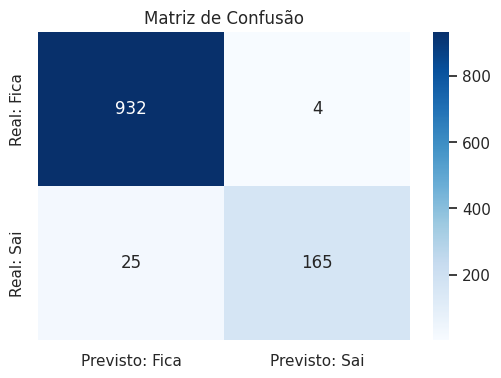

Relatório de Classificação Completo:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       936
           1       0.98      0.87      0.92       190

    accuracy                           0.97      1126
   macro avg       0.98      0.93      0.95      1126
weighted avg       0.97      0.97      0.97      1126



In [ ]:
# Calculando as métricas
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== Resultados do Modelo ===")
print(f"Acurácia:  {acc:.4f}")
print(f"Precisão:  {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}\n")

# Matriz de Confusão
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Previsto: Fica', 'Previsto: Sai'],
            yticklabels=['Real: Fica', 'Real: Sai'])
plt.title('Matriz de Confusão')
plt.show()

print("Relatório de Classificação Completo:\n")
print(classification_report(y_test, y_pred))

# **Interpretabilidade (Feature Importance)**
A grande vantagem do Random Forest é o seu alto grau de explicabilidade. O modelo consegue ranquear matematicamente quais atributos foram mais decisivos para separar os clientes que ficam dos clientes que abandonam a plataforma.

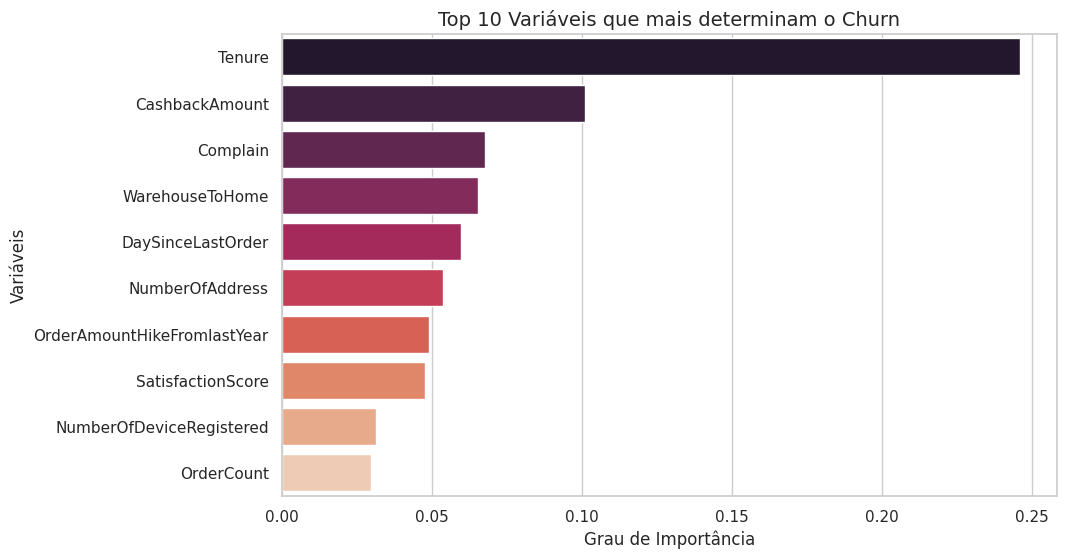

In [ ]:
# Extraindo a importância das variáveis
importancias = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

# Plotando as 10 variáveis mais importantes
plt.figure(figsize=(10, 6))
sns.barplot(x=importancias.values[:10], y=importancias.index[:10], palette='rocket')
plt.title('Top 10 Variáveis que mais determinam o Churn', fontsize=14)
plt.xlabel('Grau de Importância')
plt.ylabel('Variáveis')
plt.show()

# **Conclusão e Impacto de Negócio:**
O modelo desenvolvido demonstrou forte capacidade de identificar clientes em risco. Pela análise de importância das variáveis, notamos que atributos como Tenure (Tempo de casa), Complain (Histórico de Reclamações) e DaySinceLastOrder (Dias desde a última compra) são cruciais.

Com esta solução baseada em Python, a empresa possui agora uma ferramenta estatística para agir de forma preventiva, atacando o problema do Churn de forma cirúrgica, o que impacta diretamente na receita e no Lifetime Value (LTV) da operação logística e varejista.